<a href="https://colab.research.google.com/github/fauzilfebriwal/ADVANCE-COMPUTER-VISION/blob/main/Project_Computer_Vision_Fauzil_Febriwal_(241012050026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from sklearn.model_selection import train_test_split

Upload File ZIP Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


Extract Dataset

In [4]:
from zipfile import ZipFile

with ZipFile('archive (3).zip', 'r') as zip:
    zip.extractall('/content/dataset')

print("Dataset berhasil di extract")

Dataset berhasil di extract


In [5]:
import os

os.listdir('/content/dataset/data')

['without_mask', 'with_mask']

Load Dataset

In [6]:
data = []
labels = []

categories = ['with_mask', 'without_mask']

for category in categories:
    path = os.path.join('/content/dataset/data', category)
    label = categories.index(category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (100,100))

        data.append(image)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

Normalisasi Data

In [7]:
data = data / 255.0

Split Dataset

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Membuat Model CNN

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(100,100,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Training Model

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 102s 528ms/step - accuracy: 0.8413 - loss: 0.3705 - val_accuracy: 0.9113 - val_loss: 0.2215
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 142s 528ms/step - accuracy: 0.9050 - loss: 0.2322 - val_accuracy: 0.9292 - val_loss: 0.1982
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 97s 513ms/step - accuracy: 0.9277 - loss: 0.1882 - val_accuracy: 0.9312 - val_loss: 0.1763
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 93s 491ms/step - accuracy: 0.9366 - loss: 0.1608 - val_accuracy: 0.9371 - val_loss: 0.1631
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 97s 516ms/step - accuracy: 0.9545 - loss: 0.1251 - val_accuracy: 0.9378 - val_loss: 0.1690
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 91s 481ms/step - accuracy: 0.9657 - loss: 0.0923 - val_accuracy: 0.9351 - val_loss: 0.1779
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 146s 503ms/step - accuracy: 0.9667 - loss: 0.0881 - val_accuracy: 0.9398 - val_loss: 0.1705
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 91s 483ms/step - accuracy: 0.9714 - loss

Evaluasi Model

In [12]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy :", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.9497 - loss: 0.1736
Accuracy : 0.9497022032737732


Grafik Accuracy

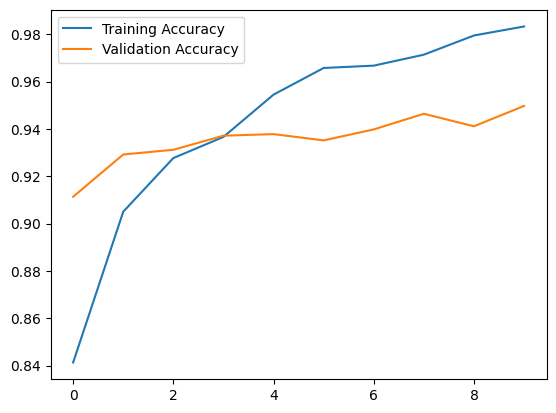

In [13]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.show()

Upload Gambar Test

In [14]:
from google.colab import files

uploaded = files.upload()

Saving test_masker2.jpg to test_masker2.jpg


Prediksi Gambar Baru

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Tidak Memakai Masker


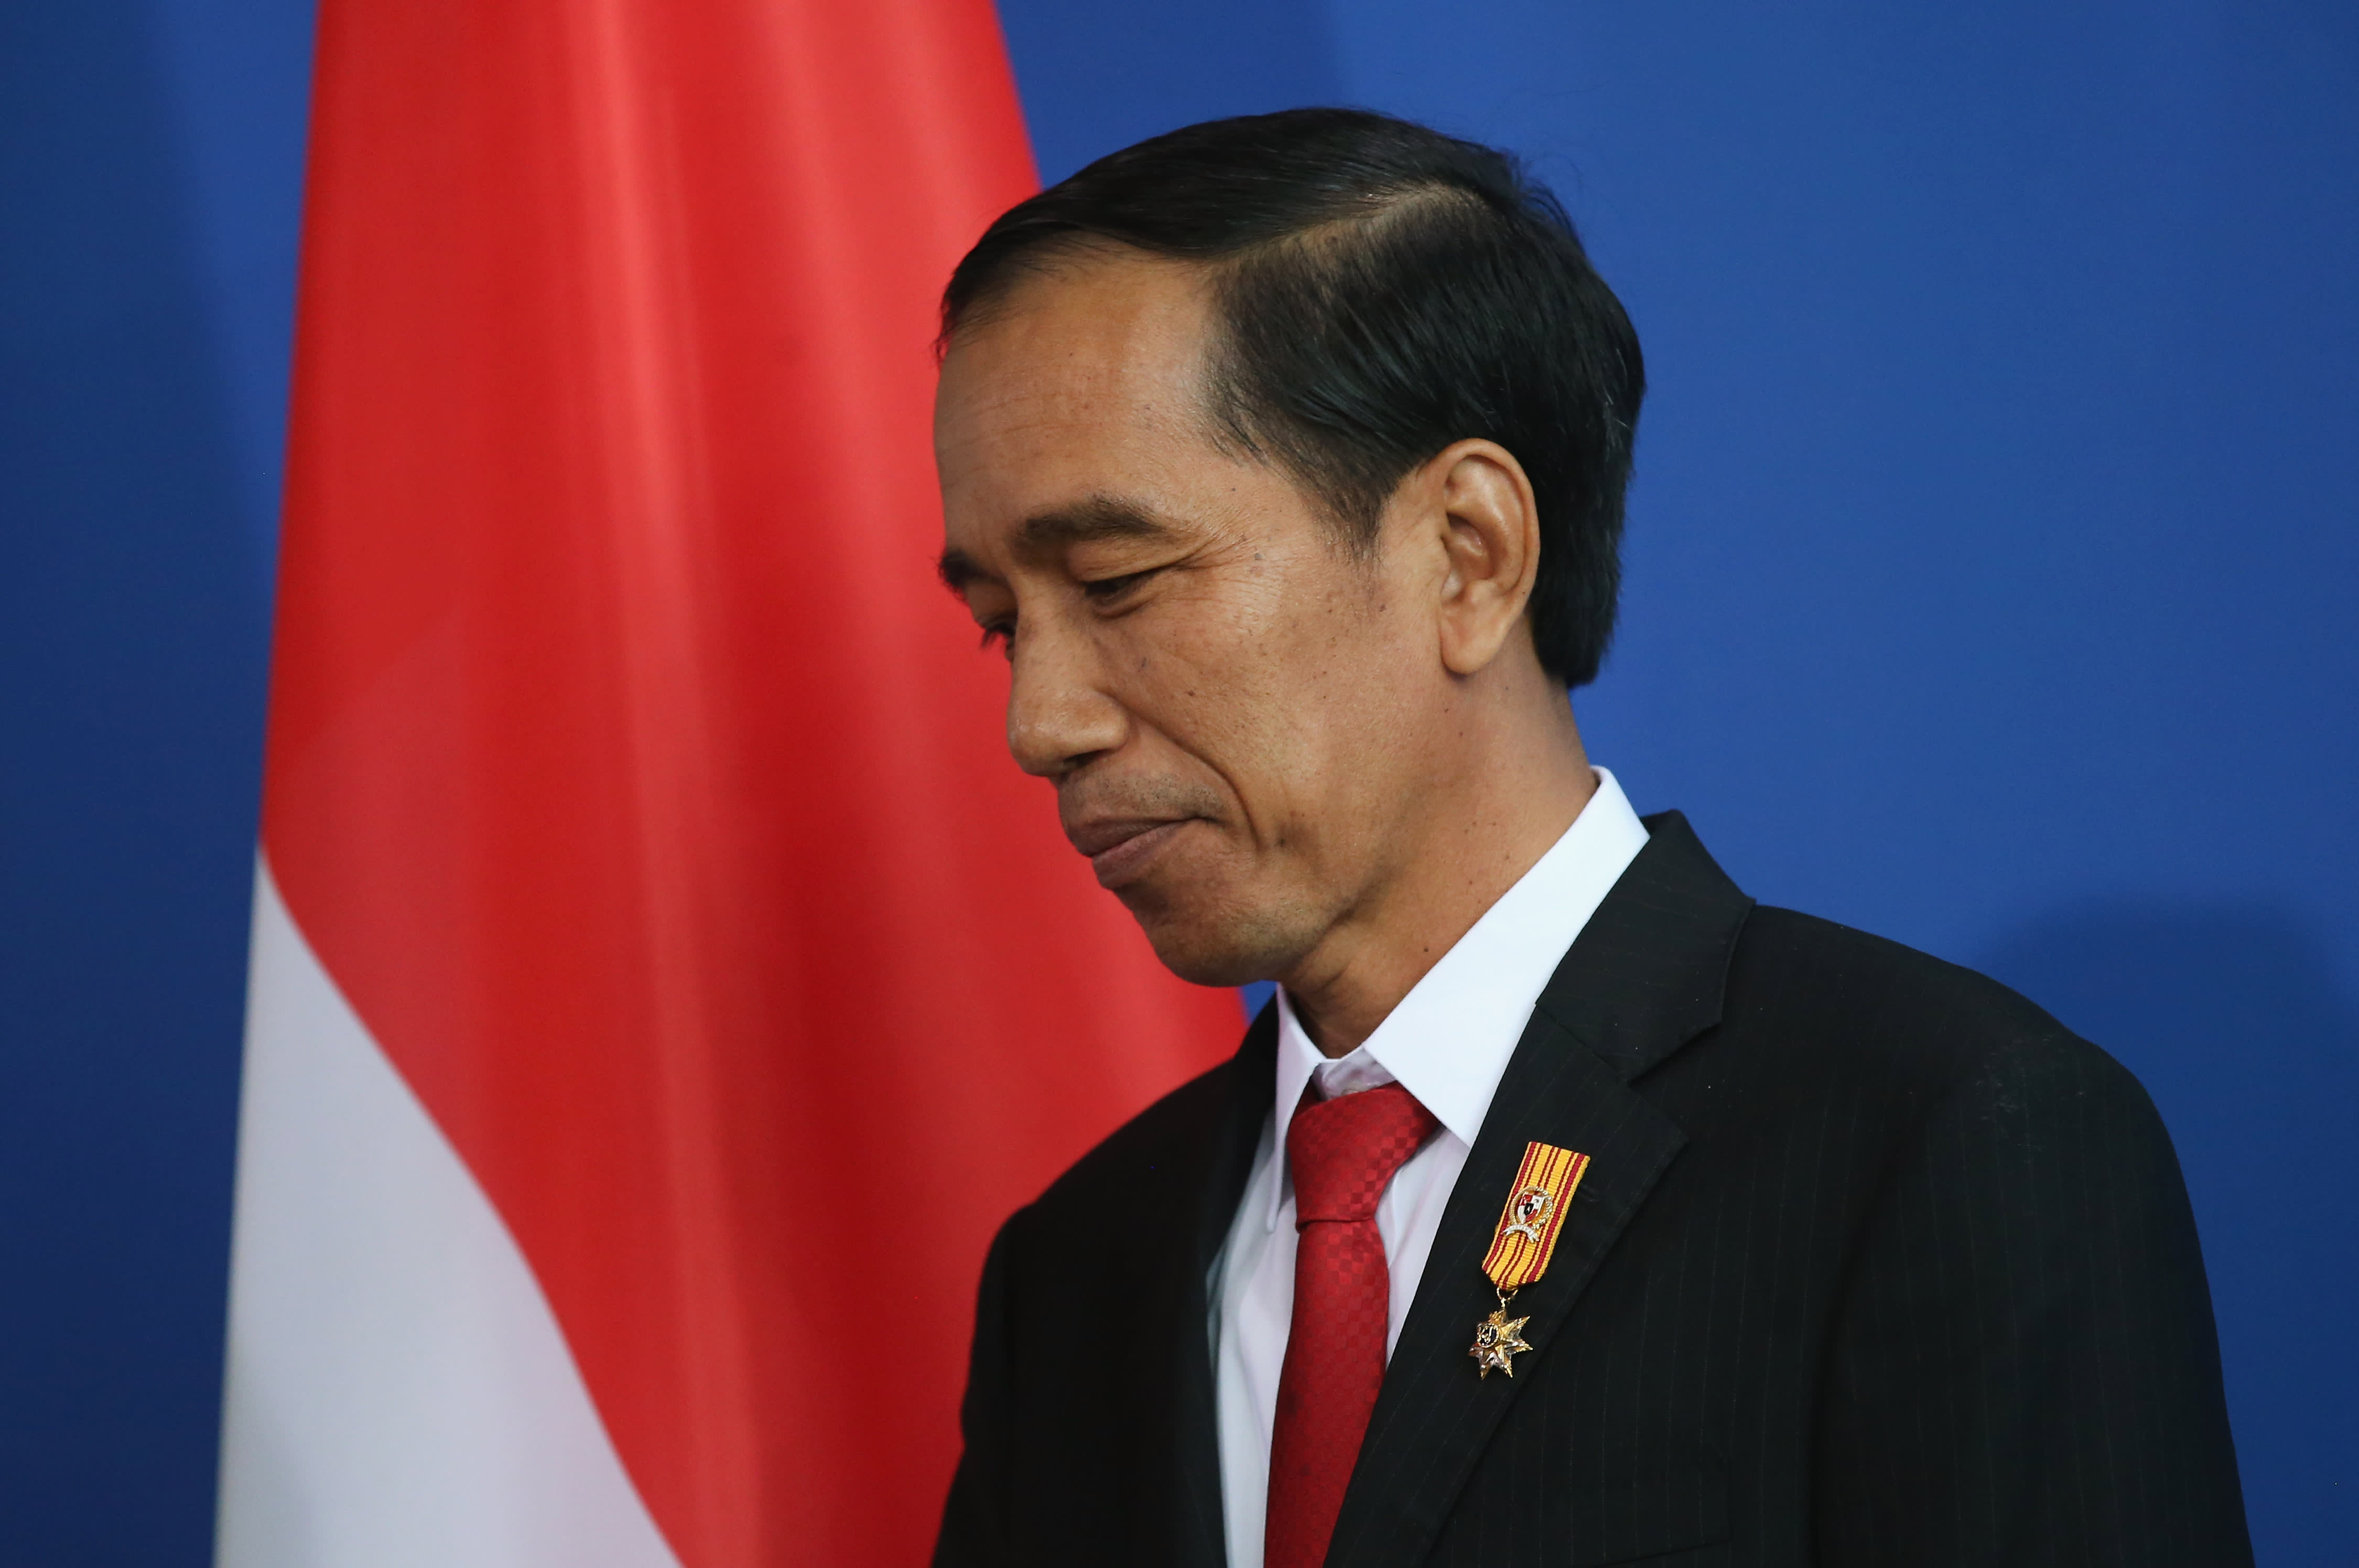

In [19]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread('/content/test_masker2.jpg')

img_resize = cv2.resize(img, (100,100))

img_resize = img_resize / 255.0

img_input = np.expand_dims(img_resize, axis=0)

prediction = model.predict(img_input)

result = np.argmax(prediction)

if result == 0:
    print("Memakai Masker")
else:
    print("Tidak Memakai Masker")

cv2_imshow(img)

In [20]:
print(categories)

['with_mask', 'without_mask']


In [21]:
print(prediction)

[[0.00661279 0.9933873 ]]


In [22]:
print("Accuracy :", accuracy)

Accuracy : 0.9497022032737732
